### Step 1: Load MNIST Dataset
MNIST images are grayscale, so there is only one channel that controls how light or dark a pixel is, unlike RGB images that have three channels <R, G, B>.

Images are 28 x 28 pixels, e.g. the sample at index 0 of train_dataset is a grayscale image represented as a tensor of shape (1, 28, 28) with the label 5.

The shape is (C, H, W), where C is the number of channels, H is height in pixels, and W is width in pixels.

In [ ]:
from torchvision import datasets, transforms

# Define a transform to convert images to tensors
#   Converts the image into a numerical array
#   Changes the layout into PyTorch’s standard format (channels, height, width)
transform = transforms.ToTensor()

# Download and load training data
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Download and load test data
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Access a single example
# train_dataset[0] returns a tuple (image dimensions, label)
image, label = train_dataset[0]
print(image.shape, label)

100.0%
100.0%
100.0%
100.0%

torch.Size([1, 28, 28]) 5


#### Show a sample image from MNIST dataset

Matplotlib expects a 2D array for grayscale images. The tensor is 3D because PyTorch explicitly stores channels. We need to squeze the tensor to get rid of the channel, e.g. (1, 28, 28) becomes (28, 28) after we squeeze.

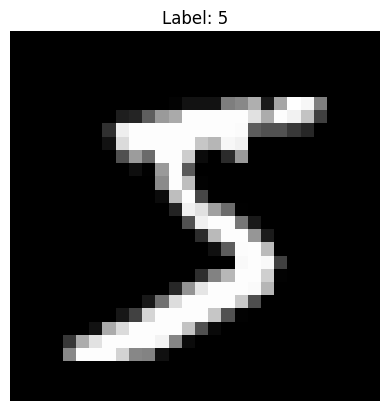

In [6]:
import matplotlib.pyplot as plt

# Get the first sample
image, label = train_dataset[0]

# Remove the channel dimension: (1, 28, 28) → (28, 28)
image_2d = image.squeeze(0)

# Plot the image
plt.imshow(image_2d, cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

### Step 2: Set aside training dataset

We will only use images labeled 0 for our training. Recall that any digit that is not 0 is treated as an anomaly.

We will train the neural network on 0s only, but the images will be corrupted with some noise.

In [ ]:
import torch
from torch.utils.data import DataLoader, Subset

# 1) Get labels from the torchvision MNIST dataset
# For MNIST, labels are stored in train_dataset.targets (a torch tensor)
targets = train_dataset.targets  # shape: (60000,)

# 2) Find indices where label == 0
zero_indices = (targets == 0).nonzero(as_tuple=True)[0]

# 3) Create a filtered dataset containing only zeros
train_dataset_0 = Subset(train_dataset, zero_indices)

print("Original train size:", len(train_dataset))
print("Filtered train size (digit 0 only):", len(train_dataset_0))

# 4) Create a DataLoader for training
train_loader_0 = DataLoader(
    train_dataset_0,
    batch_size=128, # Each batch is a tensor containing 128 grayscale images, each with 28 × 28 pixels.
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)


Original train size: 60000
Filtered train size (digit 0 only): 5923


Sanity check:
- Expect the batch size to be 128 grayscale images each with 28 x 28 pixels.
- The unique labels should only contain 0.

In [ ]:
# Grab one batch and check labels
images, labels = next(iter(train_loader_0))
print("Batch images shape:", images.shape)  # expected: [128, 1, 28, 28]
print("Unique labels in batch:", torch.unique(labels))  # expected: tensor([0])


Batch images shape: torch.Size([128, 1, 28, 28])
Unique labels in batch: tensor([0])


### Step 3: Define a range of noise strengths (sigma values)

We will corrupt the original image, $x$, with Gaussian noise, $\epsilon$, sampled from $N(0,1)$. The intensity of the noise added is controlled by $\sigma$.

$\tilde{x} = x + \sigma\epsilon$



In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Set $\sigma_{min}$ and $\sigma_{max}$ to a predefined value. We will sample $\sigma_k$ from a range defined by the $\sigma_{min}$ and $\sigma_{max}$

In [12]:
sigma_min = 0.01
sigma_max = 0.3

A helper function that returns a tensor of size $\textrm{batch\_size}$ with values of $\sigma$ bounded by $\sigma_{min}$ and $\sigma_{max}$.

The returned tensor will be added to the original images to corrupt them with noise.

In [13]:
def sample_sigma(batch_size, device):
    """
    Samples one sigma per image from a log-uniform distribution.
    Returns a tensor of shape (batch_size,)
    """
    log_sigma_min = torch.log(torch.tensor(sigma_min, device=device))
    log_sigma_max = torch.log(torch.tensor(sigma_max, device=device))

    # Uniform sampling in log-space
    log_sigma = torch.rand(batch_size, device=device) * (log_sigma_max - log_sigma_min) + log_sigma_min

    # Convert back to sigma
    sigma = torch.exp(log_sigma)
    return sigma

Sanity check
- Sigma shape must be equal to batch size
- Sigma min must be >= $\sigma_{min}$
- Sigma max must be <= $\sigma_{max}$

In [14]:
images, _ = next(iter(train_loader_0))
images = images.to(device)

batch_size = images.shape[0]

sigma = sample_sigma(batch_size, device)

print("Sigma shape:", sigma.shape)
print("Sigma min:", sigma.min().item())
print("Sigma max:", sigma.max().item())

Sigma shape: torch.Size([128])
Sigma min: 0.01019607950001955
Sigma max: 0.29829326272010803


### Step 4: Noise corruption

Generate some samples for $\epsilon$ from $N(0,1)$

In [16]:
# images: (B, 1, 28, 28)
epsilon = torch.randn_like(images)  # same shape as images, values ~ N(0,1)

In [17]:
sigma_broadcast = sigma.view(-1, 1, 1, 1)  # shape: (B, 1, 1, 1)

Corrupt the original image $x$ following the equation $\tilde{x} = x + \sigma\epsilon$

In [18]:
x_tilde = images + sigma_broadcast * epsilon

Sanity check

In [19]:
print("images:", images.shape)
print("sigma:", sigma.shape)
print("sigma_broadcast:", sigma_broadcast.shape)
print("epsilon:", epsilon.shape)
print("x_tilde:", x_tilde.shape)


images: torch.Size([128, 1, 28, 28])
sigma: torch.Size([128])
sigma_broadcast: torch.Size([128, 1, 1, 1])
epsilon: torch.Size([128, 1, 28, 28])
x_tilde: torch.Size([128, 1, 28, 28])


Visually observe the corrupted images. See how the value of $\sigma$ affects the clarity of the image.
- Larger $\sigma$ reduces the clarity of the image (i.e. more noisy)

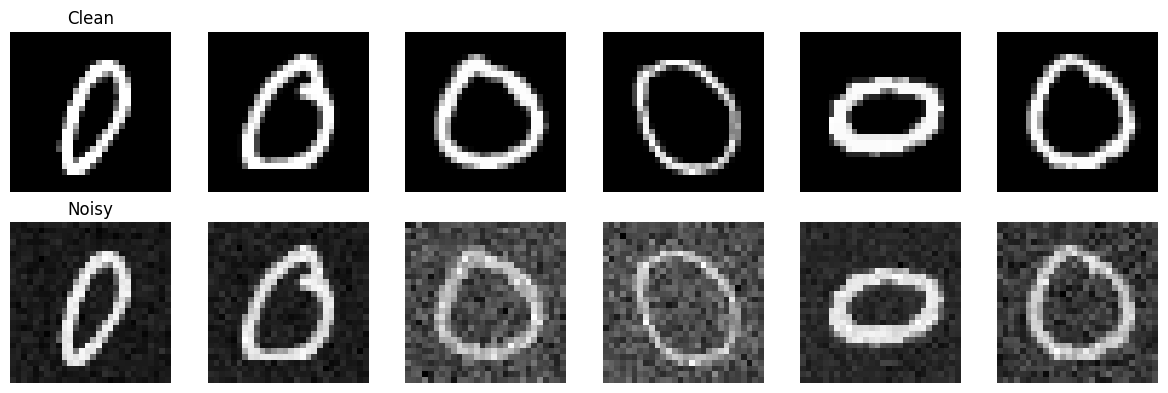

In [20]:
# Take a small subset for visualization
num_images = 6

images_vis = images[:num_images].detach().cpu()
x_tilde_vis = x_tilde[:num_images].detach().cpu()

fig, axes = plt.subplots(2, num_images, figsize=(12, 4))

for i in range(num_images):
    # Clean images (top row)
    axes[0, i].imshow(images_vis[i, 0], cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Clean")

    # Noisy images (bottom row)
    axes[1, i].imshow(x_tilde_vis[i, 0], cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Noisy")

plt.tight_layout()
plt.show()

### Step 5: Defining and training the neural network to calculate score